# 2. Pipeline con validación segura, evaluación y exportación
### Proyecto Integrador — Heart Disease MLOps (sección 10.12 del curso)

**Etapa 2 del enunciado.** Este cuaderno debe contener:
1. División de los datos **antes** de cualquier escalado/imputación.
2. Un `Pipeline` completo dentro de `GridSearchCV` -- aquí, además, se usa
   `GridSearchCV` para elegir **entre varios modelos** (el patrón de la
   sección 10.11 del curso), no solo entre hiperparámetros de uno fijo.
3. Evaluación con matriz de confusión, curva ROC y AUC.
4. Exportación del mejor modelo a `app/model.joblib`, listo para la Etapa 3 (FastAPI).


In [1]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score,
    accuracy_score, classification_report,
)

from src.pipeline_utils import load_data, split_X_y, build_preprocessor, FEATURE_ORDER

RANDOM_STATE = 42


## 1. Carga segura de los datos

`load_data()` marca `RestingBP=0` y `Cholesterol=0` como `NaN` (son valores
imposibles, no mediciones reales -- ver Notebook 1, Sección 2). Todavía **no**
se imputa nada: eso ocurre dentro del `Pipeline`.


In [2]:
df = load_data("../data/heart.csv")
X, y = split_X_y(df)
print("X:", X.shape, "| y:", y.shape)
X.head()


X: (918, 11) | y: (918,)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,40,140.0,289.0,0,172,0.0,M,ATA,Normal,N,Up
1,49,160.0,180.0,0,156,1.0,F,NAP,Normal,N,Flat
2,37,130.0,283.0,0,98,0.0,M,ATA,ST,N,Up
3,48,138.0,214.0,0,108,1.5,F,ASY,Normal,Y,Flat
4,54,150.0,195.0,0,122,0.0,M,NAP,Normal,N,Up


## 2. División train/test **antes** de escalar o imputar

Este es el paso que evita la fuga de datos: el split ocurre sobre los datos
crudos (todavía con NaN sin imputar y categorías sin codificar). El
`Pipeline` de la siguiente celda es el que aplica imputación + escalado +
one-hot **después**, y `GridSearchCV` lo reajusta en cada fold usando solo
el pliegue de entrenamiento correspondiente -- nunca el de validación.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")
print(f"Balance train: {y_train.mean():.3f} | Balance test: {y_test.mean():.3f}")


Train: 734 filas | Test: 184 filas
Balance train: 0.553 | Balance test: 0.554


## 3. `Pipeline` + `GridSearchCV`: selección entre modelos (estilo sección 10.11)

En vez de fijar un solo algoritmo, dejamos que `GridSearchCV` compare **5
familias de modelos** -- cada una con su propia rejilla de hiperparámetros --
y se quede con la combinación (modelo + hiperparámetros) de mejor AUC
promedio en validación cruzada (5 folds). Es el mismo patrón de "¿qué modelo
usar?" del capítulo, extendido de 2 a 5 candidatos.


In [4]:
preprocessor = build_preprocessor()
pipe = Pipeline([("preprocessor", preprocessor), ("model", SVC())])  # el modelo real lo decide el param_grid

param_grid = [
    {
        "model": [LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)],
        "model__C": [0.01, 0.1, 1, 10],
    },
    {
        "model": [RandomForestClassifier(random_state=RANDOM_STATE)],
        "model__n_estimators": [100, 300],
        "model__max_depth": [None, 5, 10],
    },
    {
        "model": [KNeighborsClassifier()],
        "model__n_neighbors": [3, 5, 7, 9, 11],
        "model__weights": ["uniform", "distance"],
    },
    {
        "model": [GradientBoostingClassifier(random_state=RANDOM_STATE)],
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [2, 3],
    },
    {
        "model": [SVC(probability=True, random_state=RANDOM_STATE)],
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", 0.01, 0.1],
    },
]

grid = GridSearchCV(pipe, param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train, y_train)

winner = grid.best_params_["model"]
print("Modelo ganador:", type(winner).__name__)
print("Hiperparámetros:", {k: v for k, v in grid.best_params_.items() if k != "model"})
print(f"AUC de validación cruzada (5-fold): {grid.best_score_:.4f}")


Modelo ganador: RandomForestClassifier
Hiperparámetros: {'model__max_depth': 10, 'model__n_estimators': 100}
AUC de validación cruzada (5-fold): 0.9242


`RandomForestClassifier` gana la búsqueda con el mejor AUC promedio de
validación cruzada -- consistente con el Notebook 1, donde `RandomForest` y
`GradientBoosting` ya destacaban en CV AUC (aunque no siempre en el AUC de un
solo split de test, más ruidoso). Usamos el AUC de **validación cruzada**
como criterio porque promedia 5 particiones distintas y es más confiable que
un único punto de test para decidir *qué modelo* llevar a producción.


## 4. Evaluación en el conjunto de prueba

In [5]:
y_pred = grid.predict(X_test)
y_proba = grid.predict_proba(X_test)[:, 1]

print(f"Accuracy (test): {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC (test):      {roc_auc_score(y_test, y_proba):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Sin enfermedad", "Con enfermedad"]))


Accuracy (test): 0.8859
AUC (test):      0.9321

                precision    recall  f1-score   support

Sin enfermedad       0.88      0.87      0.87        82
Con enfermedad       0.89      0.90      0.90       102

      accuracy                           0.89       184
     macro avg       0.88      0.88      0.88       184
  weighted avg       0.89      0.89      0.89       184



### 4.1 Matriz de confusión

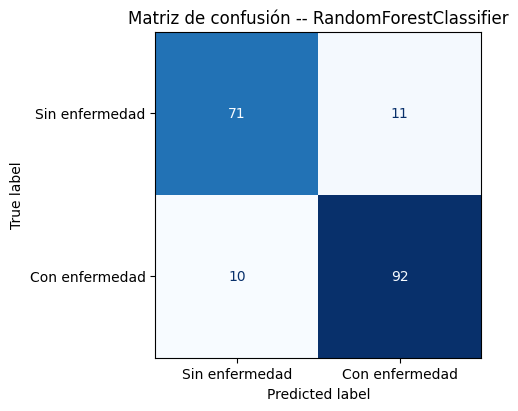

In [6]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Sin enfermedad", "Con enfermedad"],
    cmap="Blues", ax=ax, colorbar=False,
)
ax.set_title(f"Matriz de confusión -- {type(winner).__name__}")
plt.tight_layout()
plt.show()


### 4.2 Curva ROC

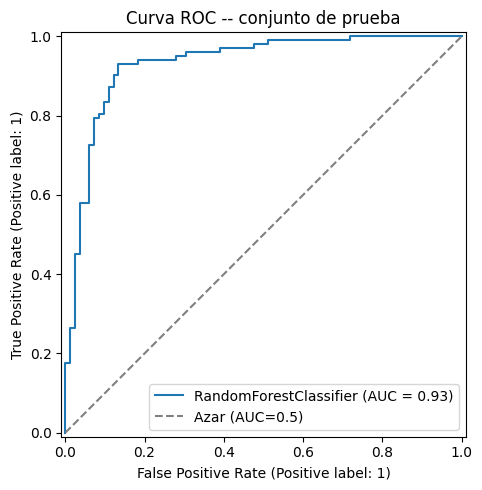

In [7]:
fig, ax = plt.subplots(figsize=(5.5, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name=type(winner).__name__)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar (AUC=0.5)")
ax.set_title("Curva ROC -- conjunto de prueba")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Exportar el modelo final para la Etapa 3 (FastAPI)

Se exporta `grid.best_estimator_`: el `Pipeline` **completo** (preprocesador +
modelo ganador ya ajustados), no solo el clasificador. Así, `app/api.py` puede
recibir features crudas (sin escalar, sin codificar) y el propio pipeline se
encarga de transformarlas exactamente igual que en entrenamiento.


In [8]:
import os
os.makedirs("../app", exist_ok=True)
joblib.dump(grid.best_estimator_, "../app/model.joblib")
print("Modelo guardado en app/model.joblib")
print("Tamaño:", round(os.path.getsize('../app/model.joblib') / 1024, 1), "KB")


Modelo guardado en app/model.joblib
Tamaño: 1637.1 KB


### 5.1 Prueba de humo: recargar el modelo y predecir un registro

Antes de pasar a la API, confirmamos que el artefacto exportado funciona de
forma independiente -- exactamente como lo cargará `app/api.py` en producción.


In [9]:
reloaded = joblib.load("../app/model.joblib")

sample = X_test.iloc[[0]]
proba = reloaded.predict_proba(sample)[0, 1]
pred = int(proba > 0.5)

print("Features de ejemplo (orden esperado):", FEATURE_ORDER)
print(sample.to_dict(orient="records")[0])
print(f"\nProbabilidad de enfermedad cardíaca: {proba:.4f}  ->  Predicción: {pred}  |  Real: {int(y_test.iloc[0])}")


Features de ejemplo (orden esperado): ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
{'Age': 46, 'RestingBP': 115.0, 'Cholesterol': nan, 'FastingBS': 0, 'MaxHR': 113, 'Oldpeak': 1.5, 'Sex': 'M', 'ChestPainType': 'ASY', 'RestingECG': 'Normal', 'ExerciseAngina': 'Y', 'ST_Slope': 'Flat'}

Probabilidad de enfermedad cardíaca: 0.9763  ->  Predicción: 1  |  Real: 1


## 6. Conclusiones de la Etapa 2

- El split se hizo **antes** de imputar/escalar/codificar; toda esa lógica
  vive dentro del `Pipeline`, así que no hay fuga de información del conjunto
  de prueba hacia el entrenamiento.
- `GridSearchCV` no solo ajustó hiperparámetros: **eligió el modelo** entre 5
  familias distintas usando AUC de validación cruzada -- `RandomForestClassifier`
  resultó ganador.
- La matriz de confusión y la curva ROC confirman un desempeño sólido y
  balanceado entre ambas clases, coherente con el AUC de validación cruzada.
- El pipeline completo (no solo el modelo) quedó guardado en
  `app/model.joblib`, listo para servirse desde la API de la Etapa 3.
